In [ ]:
!pip install nltk


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
url = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"
df = pd.read_csv(url)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    text = text.split()
    text = [word for word in text if word not in stopwords.words('english')]
    return ' '.join(text)

df['cleaned_review'] = df['review'].apply(clean_text)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_review']).toarray()

y = df['sentiment'].map({'positive':1, 'negative':0})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8867


In [ ]:
def predict_sentiment(text):
    text = clean_text(text)
    text = vectorizer.transform([text]).toarray()
    result = model.predict(text)[0]
    return "Positive" if result == 1 else "Negative"

print(predict_sentiment("This product is amazing"))
print(predict_sentiment("Worst experience ever"))

Positive
Negative


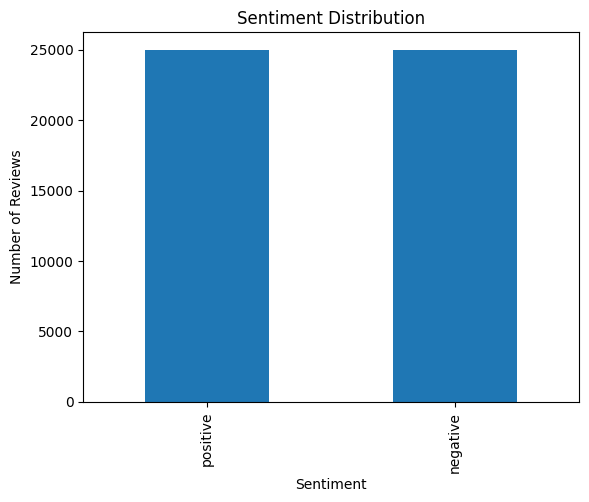

In [9]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Naive Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.8538


In [11]:
# Logistic Regression metrics
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

# Naive Bayes metrics
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print("=== Model Comparison ===")
print(f"{'Metric':<12} {'Logistic Reg':>15} {'Naive Bayes':>15}")
print(f"{'Accuracy':<12} {0.8867:>15.4f} {nb_accuracy:>15.4f}")
print(f"{'Precision':<12} {lr_precision:>15.4f} {nb_precision:>15.4f}")
print(f"{'Recall':<12} {lr_recall:>15.4f} {nb_recall:>15.4f}")
print(f"{'F1 Score':<12} {lr_f1:>15.4f} {nb_f1:>15.4f}")

=== Model Comparison ===
Metric          Logistic Reg     Naive Bayes
Accuracy              0.8867          0.8538
Precision             0.8816          0.8512
Recall                0.8951          0.8597
F1 Score              0.8883          0.8554


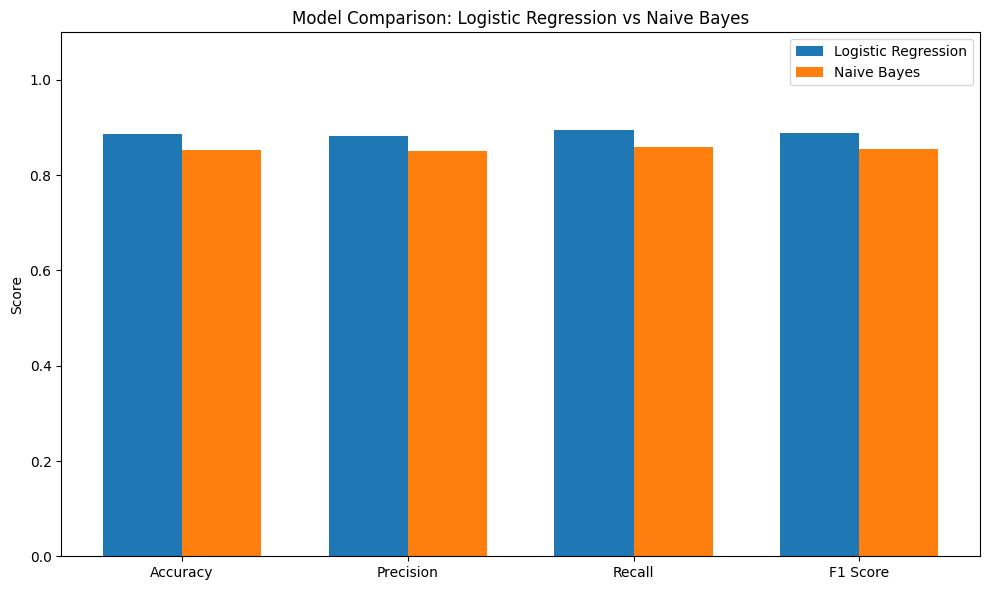

In [12]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores = [0.8867, lr_precision, lr_recall, lr_f1]
nb_scores = [nb_accuracy, nb_precision, nb_recall, nb_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, lr_scores, width, label='Logistic Regression')
ax.bar(x + width/2, nb_scores, width, label='Naive Bayes')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs Naive Bayes')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()